<a href="https://colab.research.google.com/github/nipuninduwaraedu/SE4050-Assignment-/blob/member4-model4/06_Model4_GRU_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
import os
os.listdir("/content")


['.config', 'prepared_har_data.npz.zip', '.ipynb_checkpoints', 'sample_data']

In [10]:
import zipfile, os

zip_path = "/content/prepared_har_data.npz.zip"
extract_dir = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))


Extracted files: ['.config', 'y_validation.npy', 'subject_train.npy', 'y_train.npy', 'X_train.npy', 'activity_names.npy', 'X_validation.npy', 'y_test.npy', 'subject_validation.npy', 'X_test.npy', 'subject_test.npy', 'prepared_har_data.npz.zip', '.ipynb_checkpoints', 'sample_data']


In [12]:
print("Extracted files:", os.listdir("/content"))

Extracted files: ['.config', 'y_validation.npy', 'subject_train.npy', 'y_train.npy', 'X_train.npy', 'activity_names.npy', 'X_validation.npy', 'y_test.npy', 'subject_validation.npy', 'X_test.npy', 'subject_test.npy', 'prepared_har_data.npz.zip', '.ipynb_checkpoints', 'sample_data']


In [14]:
import numpy as np

X_train = np.load("/content/X_train.npy", allow_pickle=True)
y_train = np.load("/content/y_train.npy", allow_pickle=True)
X_test  = np.load("/content/X_test.npy", allow_pickle=True)
y_test  = np.load("/content/y_test.npy", allow_pickle=True)

X_val   = np.load("/content/X_validation.npy", allow_pickle=True)
y_val   = np.load("/content/y_validation.npy", allow_pickle=True)

activity_names = np.load("/content/activity_names.npy", allow_pickle=True)


In [18]:
# ============================================
# Step 2: Check Dataset Shapes
# ============================================

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Testing data:", X_test.shape, y_test.shape)

print("\nActivity Names:")
print(activity_names)

Training data: (5551, 128, 9) (5551,)
Validation data: (1801, 128, 9) (1801,)
Testing data: (2947, 128, 9) (2947,)

Activity Names:
['WALKING' 'WALKING_UPSTAIRS' 'WALKING_DOWNSTAIRS' 'SITTING' 'STANDING'
 'LAYING']


In [15]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Activities:", activity_names)


Train: (5551, 128, 9) (5551,)
Validation: (1801, 128, 9) (1801,)
Test: (2947, 128, 9) (2947,)
Activities: ['WALKING' 'WALKING_UPSTAIRS' 'WALKING_DOWNSTAIRS' 'SITTING' 'STANDING'
 'LAYING']


In [19]:
# ============================================
# Step 3: Check Unique Activity Labels
# ============================================

print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_val))
print("Unique testing labels:", np.unique(y_test))

Unique training labels: [0 1 2 3 4 5]
Unique validation labels: [0 1 2 3 4 5]
Unique testing labels: [0 1 2 3 4 5]


In [20]:
# ============================================
# Step 4: Import Required Libraries
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [21]:
# ============================================
# Step 5: Check Data Type and Value Range
# ============================================

print("X_train data type:", X_train.dtype)
print("X_train minimum value:", X_train.min())
print("X_train maximum value:", X_train.max())

print("y_train data type:", y_train.dtype)

X_train data type: float32
X_train minimum value: -15.19651
X_train maximum value: 14.620516
y_train data type: int64


In [22]:
# ============================================
# Step 6: Build Model 4 - GRU Architecture
# ============================================

model = Sequential([
    GRU(64, input_shape=(128, 9)),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(6, activation='softmax')
])

# Display the model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,678 (65.15 KB)

 Trainable params: 16,678 (65.15 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================
# Step 7: Compile the GRU Model
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("GRU model compiled successfully!")

GRU model compiled successfully!


In [24]:
# ============================================
# Step 8: Configure Early Stopping
# ============================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Early stopping configured successfully!")

Early stopping configured successfully!


In [25]:
# ============================================
# Step 9: Train the GRU Model
# ============================================

# Start measuring training time
start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Calculate total training time
end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed!")
print("Training Time:", training_time, "seconds")

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.4999 - loss: 1.3368 - val_accuracy: 0.6280 - val_loss: 0.9481
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.6729 - loss: 0.7596 - val_accuracy: 0.8073 - val_loss: 0.5421
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.7575 - loss: 0.5506 - val_accuracy: 0.8329 - val_loss: 0.4356
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8552 - loss: 0.3510 - val_accuracy: 0.9450 - val_loss: 0.1949
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9146 - loss: 0.2171 - val_accuracy: 0.9445 - val_loss: 0.2178
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9112 - loss: 0.2180 - val_accuracy: 0.9706 - val_loss: 0.1340
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9215 - loss: 0.1802 - val_accuracy: 0.9184 - val_loss: 0.3256
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9234 - loss: 0.1704 - val_accuracy

In [26]:
# ============================================
# Step 10: Evaluate GRU Model on Test Data
# ============================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8935 - loss: 0.2855

Test Loss: 0.28554409742355347
Test Accuracy: 0.8934509754180908


In [27]:
# ============================================
# Step 11: Generate Predictions for Test Data
# ============================================

# Generate prediction probabilities
y_pred_probability = model.predict(
    X_test,
    verbose=0
)

# Convert probabilities into predicted class labels
y_pred = np.argmax(
    y_pred_probability,
    axis=1
)

print("Predictions generated successfully!")
print("Predictions shape:", y_pred.shape)
print("Actual labels shape:", y_test.shape)

Predictions generated successfully!
Predictions shape: (2947,)
Actual labels shape: (2947,)


In [28]:
# ============================================
# Step 12: Calculate Classification Metrics
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("GRU Model 4 Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

GRU Model 4 Results
----------------------------
Accuracy : 0.8934509670851714
Precision: 0.9020862822961941
Recall   : 0.8934509670851714
F1 Score : 0.8914908958829355


In [29]:
# ============================================
# Step 13: Generate Classification Report
# ============================================

classification_rep = classification_report(
    y_test,
    y_pred,
    target_names=activity_names
)

print(classification_rep)

                    precision    recall  f1-score   support

           WALKING       0.88      0.98      0.93       496
  WALKING_UPSTAIRS       0.92      0.95      0.93       471
WALKING_DOWNSTAIRS       1.00      0.87      0.93       420
           SITTING       0.89      0.64      0.75       491
          STANDING       0.75      0.93      0.83       532
            LAYING       0.99      0.98      0.98       537

          accuracy                           0.89      2947
         macro avg       0.91      0.89      0.89      2947
      weighted avg       0.90      0.89      0.89      2947



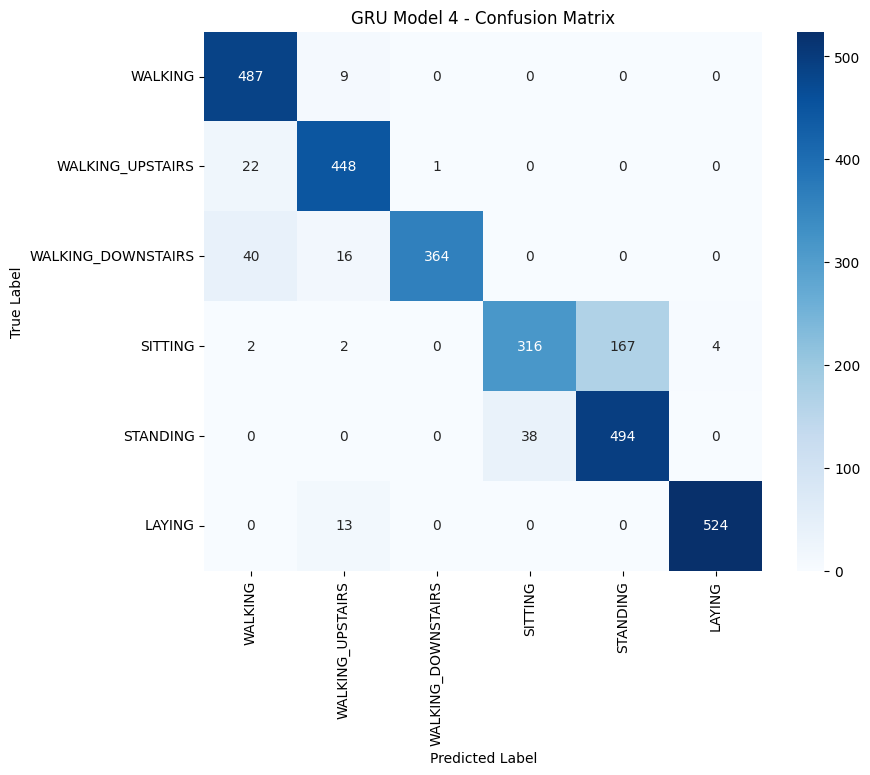

In [30]:
# ============================================
# Step 14: Generate Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU Model 4 - Confusion Matrix")

plt.show()

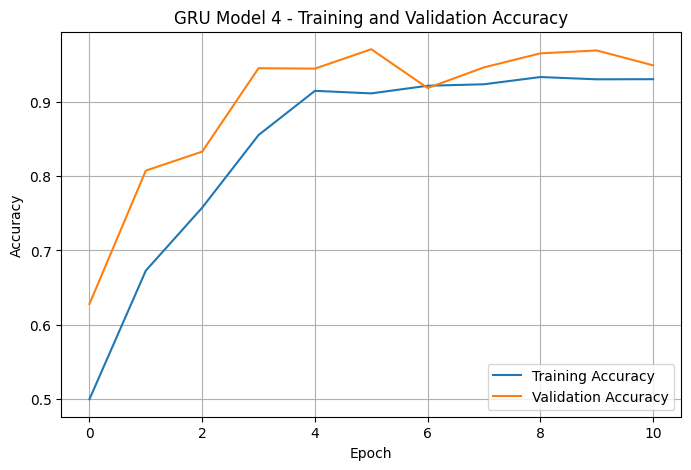

In [31]:
# ============================================
# Step 15: Plot Training and Validation Accuracy
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Model 4 - Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

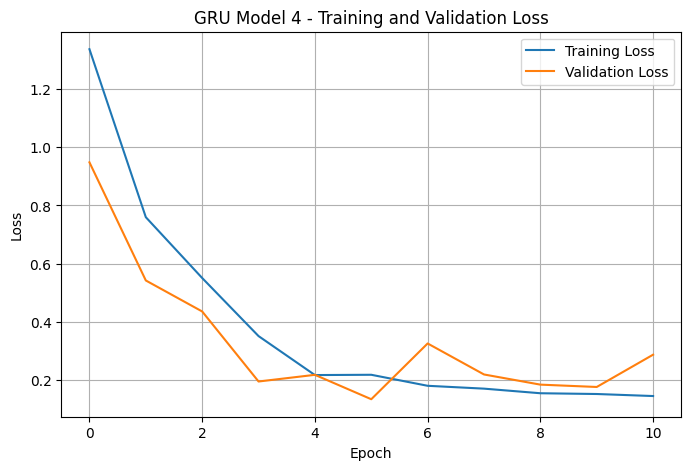

In [32]:
# ============================================
# Step 16: Plot Training and Validation Loss
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Model 4 - Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [33]:
# ============================================
# Step 17: Calculate Total Model Parameters
# ============================================

total_parameters = model.count_params()

print("Total GRU Model Parameters:", total_parameters)

Total GRU Model Parameters: 16678


In [34]:
# ============================================
# Step 18: Create GRU Model Results Table
# ============================================

results = pd.DataFrame({
    "Model": ["GRU"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "Training_Time_Seconds": [training_time],
    "Parameters": [total_parameters]
})

results

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time_Seconds,Parameters
0,GRU,0.893451,0.902086,0.893451,0.891491,106.625998,16678


In [35]:
# ============================================
# Step 19: Save GRU Model and Results
# ============================================

import os

# Create the Model 4 results directory
os.makedirs("/content/results/model4", exist_ok=True)

# Save performance metrics
results.to_csv(
    "/content/results/model4/metrics.csv",
    index=False
)

# Save trained GRU model
model.save(
    "/content/results/model4/gru_model.keras"
)

print("Model and results saved successfully!")

Model and results saved successfully!


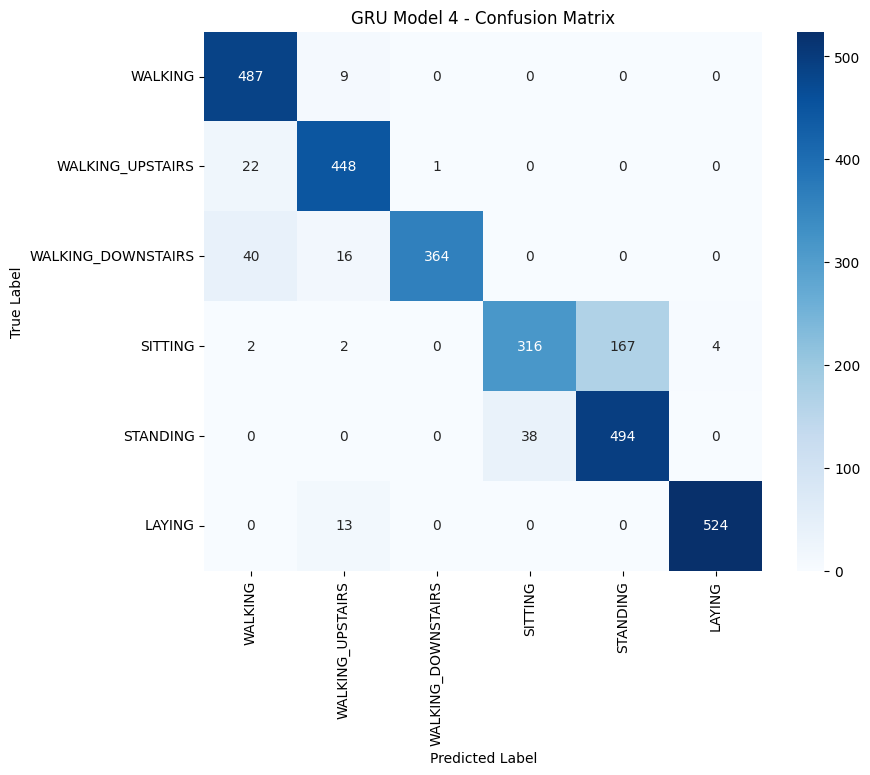

In [36]:
# ============================================
# Step 20: Save Confusion Matrix Figure
# ============================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU Model 4 - Confusion Matrix")

plt.savefig(
    "/content/results/model4/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

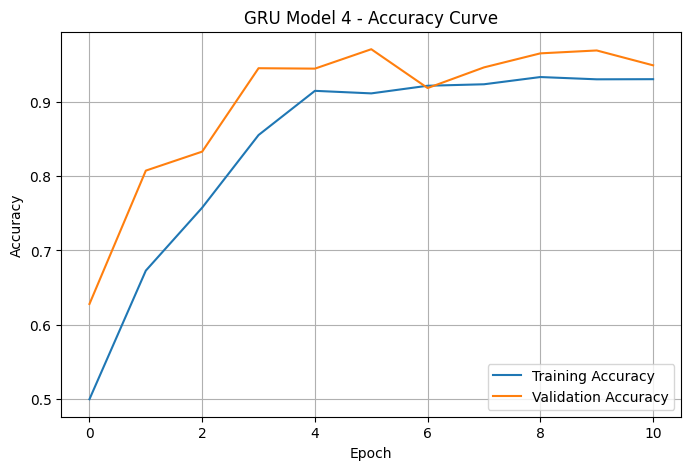

In [37]:
# ============================================
# Step 21: Save Accuracy Curve
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Model 4 - Accuracy Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "/content/results/model4/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

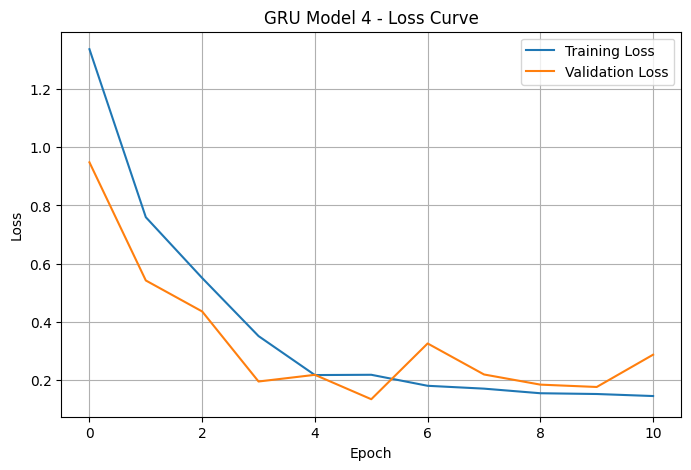

In [38]:
# ============================================
# Step 22: Save Loss Curve
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Model 4 - Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "/content/results/model4/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Check saved Model 4 results

import os

print(os.listdir("/content/results/model4"))

['accuracy_curve.png', 'loss_curve.png', 'metrics.csv', 'gru_model.keras', 'confusion_matrix.png']


In [40]:
# Display final GRU Model 4 results

print(results)
print("\nTraining Time:", training_time)
print("Total Parameters:", model.count_params())

  Model  Accuracy  Precision    Recall  F1_Score  Training_Time_Seconds  \
0   GRU  0.893451   0.902086  0.893451  0.891491             106.625998   

   Parameters  
0       16678  

Training Time: 106.62599849700928
Total Parameters: 16678


In [41]:
# Step 23: Verify the final GRU results

print(results)

results.to_csv(
    "/content/results/model4/metrics.csv",
    index=False
)

print("\nGRU Model 4 results saved successfully!")

  Model  Accuracy  Precision    Recall  F1_Score  Training_Time_Seconds  \
0   GRU  0.893451   0.902086  0.893451  0.891491             106.625998   

   Parameters  
0       16678  

GRU Model 4 results saved successfully!
